### 1. Familiarize with dataset

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC

data: pd.DataFrame = pd.read_csv("train.csv")
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [52]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [53]:
data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [54]:
data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [55]:
data["Transported"].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

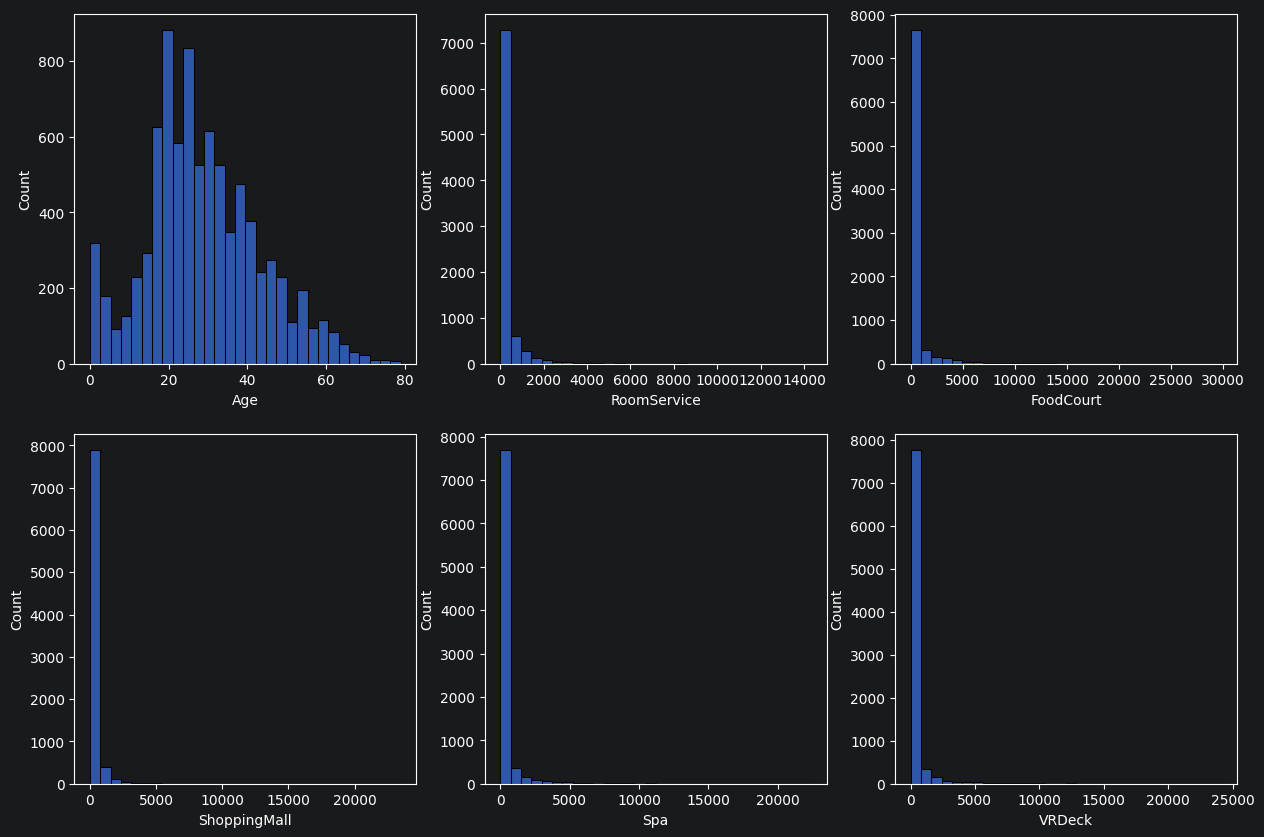

In [56]:
num_cols = data.select_dtypes(exclude=["object", "str", "bool"]).columns.to_list()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sea.histplot(data=data, x=col, ax=axes[i], bins=30)
plt.show()

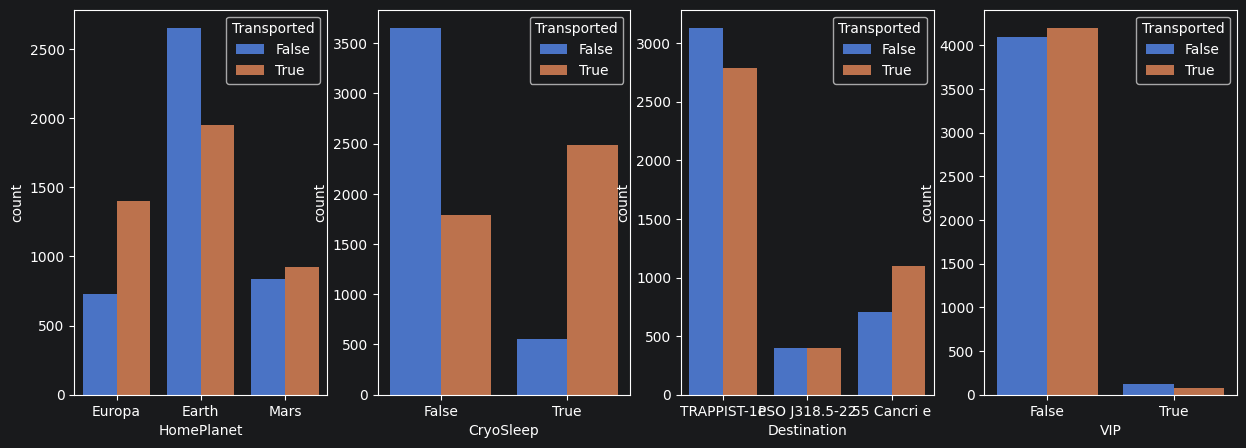

In [57]:
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sea.countplot(data=data, x=col, hue="Transported", ax=axes[i])

plt.show()

### 2. Create Pipeline

In [58]:
X = data.drop(columns=["Transported"])
y = data["Transported"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
def sum_spend_money(X):
    X = X.copy()
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    X["TotalSpend"] = X[spend_cols].sum(axis=1)
    return X

X_TotalSpend = FunctionTransformer(sum_spend_money)

In [60]:
num_features = X_train.select_dtypes(exclude=["object", "str", "bool"]).columns.to_list()
cat_features = X_train.select_dtypes(exclude=["float64"]).columns.to_list()
num_features_v2 = num_features + ["TotalSpend"]

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

all_data = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
])

all_data_v2 = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features_v2),
    ('cat', cat_pipeline, cat_features),
])

### 3. Baseline (LinearSVC)

In [61]:
full_model = make_pipeline(all_data, LinearSVC(C=1.0, loss="hinge", random_state=42))

cross_validation = cross_val_score(full_model, X, y, cv=5, scoring="accuracy")
print(f"All scores: {cross_validation}")
print(f"Mean: {cross_validation.mean()}")

All scores: [0.77975848 0.77745831 0.77458309 0.78078251 0.79689298]
Mean: 0.7818950748118537


### 4. GridSearchCV Baseline

In [62]:
param_grid = {
    "linearsvc__C": [0.01, 0.1, 1.0, 10.0 , 100.0],
    "linearsvc__loss": ["hinge", "squared_hinge"]
}

grid_search = GridSearchCV(
    estimator=full_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'linearsvc__C': 0.1, 'linearsvc__loss': 'squared_hinge'}
Best score: 0.7894749908197094


### 5. Model v2 with TotalSpend Column

In [63]:
full_model_v2 = make_pipeline(X_TotalSpend, all_data_v2, LinearSVC(C=1.0, loss="hinge", random_state=42))

param_grid = {
    "linearsvc__C": [0.01, 0.1, 1.0, 10.0 , 100.0],
    "linearsvc__loss": ["hinge", "squared_hinge"]
}

grid_search = GridSearchCV(
    estimator=full_model_v2,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'linearsvc__C': 0.1, 'linearsvc__loss': 'hinge'}
Best score: 0.7899055076571381


### 6. Model v3 SVC(kernel="linear")

In [64]:
full_model_v3 = make_pipeline(X_TotalSpend, all_data_v2, SVC(kernel="linear", random_state=42))
param_grid = {
    "svc__C": [0.01, 0.1, 1.0, 10.0],
}

grid_search = GridSearchCV(
    estimator=full_model_v3,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'svc__C': 0.1}
Best score: 0.7899055076571381


### 7. Model v4 SVC(kernel="poly")

In [65]:
full_model_v4 = make_pipeline(X_TotalSpend, all_data_v2, SVC(kernel="poly", random_state=42))
param_grid = {
    "svc__C": [0.01, 0.1, 1.0, 10.0],
    "svc__degree": [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=full_model_v4,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'svc__C': 10.0, 'svc__degree': 3}
Best score: 0.7922068384113701


### 7. Model v5 SVC(kernel="rbf")

In [66]:
full_model_v5 = make_pipeline(X_TotalSpend, all_data_v2, SVC(kernel="rbf", random_state=42))
param_grid = {
    "svc__C": [10.0, 10.4, 10.8, 11.0],
    "svc__gamma": ["scale", 0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(
    estimator=full_model_v5,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

Best parameters: {'svc__C': 10.0, 'svc__gamma': 'scale'}
Best score: 0.7953700303596087


### 8. Kaggle Model

In [68]:
X_test = pd.read_csv("test.csv")

test_id = X_test["PassengerId"]
final_model = make_pipeline(X_TotalSpend, all_data_v2, SVC(kernel="rbf", C=10.0, gamma="scale", random_state=42))
final_model.fit(X, y)

predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_id,
    "Transported": predictions.astype(bool)
})
submission.to_csv("submission.csv", index=False)

print(submission.head())
print(f"Liczba predykcji: {len(submission)}")

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
Liczba predykcji: 4277
